In [66]:
import os
import torch
import rasterio
import numpy as np
from pathlib import Path
import h5py
from typing import Dict, Any
import matplotlib.pyplot as plt
from dataloader_CIRCA.datasets.UTILISE_ligth import CIRCA_HDF5_Dataset

from lib import config_utils
from lib import data_utils
from lib import visutils # gallery / apply_brightness_factor / sequence2gallery 

from lib.eval_tools import (
    Imputation,
    visualize_att_for_one_head_across_time,
    visualize_att_for_target_t_across_heads
)


#### Arguments nécessaires:  
&emsp;- paramètres modèles (à redéfinir) / paramètres provenant d'une conf ayant servi pour un training  
&emsp;- paramètres liés à la donnée (config.data / config.mask / config.method)    
&emsp;- liste des métriques que l'on souhaite calculée config.metrics    
&emsp;- nombre de worker => config.misc (même si le reste des params ne sert pas vraiment) ..  
&emsp;- argument au nivau des noms des fichiers / répertoires pour les outputs config.output  

=> **conclusion:** Passage par un fichier de config pour lancer le notebook d'inférence 

In [67]:
def get_sample(
    dataloader: torch.utils.data.dataloader.DataLoader,
    sample_index: int
) -> Dict[str, Any]:
    
    batch = dataloader.dataset.__getitem__(sample_index)
    
    # Introduce the batch dimension (required for the forward pass)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0)
        elif isinstance(v, int):
            batch[k] = [v]

    return batch

In [68]:
# Path to the data
store_dai = Path('/mnt/stores/store-dai/')
rpg_data = Path('/home/SPeillet/cloud_reconstruction/data')
circa_hdf5 = rpg_data / 'circa' / 'hdf5' / 'circa_cloud_removal.hdf5'
outputs_folder = rpg_data / 'outputs' / 'U-TILISE'

# Verify that the paths exist
assert store_dai.exists(), f"Store path {store_dai} does not exist."
assert rpg_data.exists(), f"RPG data path {rpg_data} does not exist."
assert circa_hdf5.exists(), f"Circa HDF5 file {circa_hdf5} does not exist."

In [69]:
num_workers_LNV = 8 
batch_size_inference = 1

filter_settings = {
    "type": "cloud-free",  # Strategy for removing observations with data gaps.
    # ['cloud-free', 'cloud-free_consecutive']
    "min_length": 10,  # Minimum sequence length.
    "return_valid_obs_only": True,  # True to return the cloud-filtered sequences, False otherwise.
    # "max_t_sampling": 10,            # Maximum temporal sampling frequency in days.
}

mask_kwargs = {
    "mask_type": "real_clouds",  # Mask the input time series with randomly sampled cloud masks or the actual cloud masks. ['random_clouds', 'real_clouds']
    "ratio_masked_frames": 0.5,  # Ratio of partially/fully masked images per image time series (upper bound).
    "ratio_fully_masked_frames": 1.0,  # Ratio of fully masked images per image time series (upper bound).
    "fixed_masking_ratio": False,  # True to vary the masking ratio across different image time series, False otherwise.
    "non_masked_frames": [
        0
    ],  # list of int, time steps to be excluded from masking. E.g., [0] never masks the first frame in a sequence.
    "intersect_real_cloud_masks": True,  # True to intersect randomly sampled cloud masks with the actual cloud masks, False otherwise.
    "dilate_cloud_masks": True,  # True to dilate the cloud masks before masking, False otherwise.
    "fill_type": "fill_value",  # Strategy for initializing masked pixels. ['fill_value', 'white_noise', 'mean']
    "fill_value": 1,  # Pixel value of masked pixels. Used if fill_type == 'fill_value'.
    "p_filter": 0.1,
}

test_dset = CIRCA_HDF5_Dataset(
    hdf5_file_read=circa_hdf5,
    shuffle=False,
    include_S1=False,
    phase="test",
    mask_kwargs=mask_kwargs,
    filter_settings=filter_settings,    
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dset,
    batch_size=batch_size_inference,
    shuffle=False,
    num_workers=1,
    collate_fn=None,
    pin_memory=False,
    drop_last=False,
)

# sample = next(iter(test_loader))
# print(sample.keys())

In [70]:
from lib.eval_tools import Imputation
from lib import config_utils
path_inference_config_file = Path("/home/SPeillet/cloud_reconstruction/U-TILISE/configs/inference_circa.yaml")
path_ckpt_config_file = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/config.yaml")
path_ckpt_pth = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/checkpoints/Model_best.pth")
training_config_file = config_utils.read_config(path_ckpt_config_file)
inference_config_file = config_utils.read_config(path_inference_config_file)

# Faire la différence entre l'imputation d'une TS (avec plusieurs intervalles de dates) et plusieurs observations.
inference_imputation = Imputation(
    config_file_train=path_inference_config_file, # Config permettant de faire la configuration de l'inference
    method="utilise",
    checkpoint=path_ckpt_pth,
    config_file_test=path_ckpt_config_file, # Fichier ayant servi à l'entrainement du modèle (update params model)
)

/home/SPeillet/cloud_reconstruction/U-TILISE/lib/eval_tools.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(self.checkpoint)


Checkpoint '/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/checkpoints/Model_best.pth' loaded.
Chosen epoch: 102



In [71]:
print("Information sur l'imputation:")
print(30 * "=")
print(f"{inference_imputation.config_file_train=}")
print(f"{inference_imputation.checkpoint=}")
print(f"{inference_imputation.method=}")
print(f"{inference_imputation.mode=}")
print(f"{inference_imputation.temporal_window=}")
print(f"{inference_imputation.num_channels=}")
print(f"{inference_imputation.device=}")
print(f"{inference_imputation.model=}")

Information sur l'imputation:
inference_imputation.config_file_train=PosixPath('/home/SPeillet/cloud_reconstruction/U-TILISE/configs/inference_circa.yaml')
inference_imputation.checkpoint=PosixPath('/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/checkpoints/Model_best.pth')
inference_imputation.method=<Method.UTILISE: 'utilise'>
inference_imputation.mode=<Mode.NONE: None>
inference_imputation.temporal_window=15
inference_imputation.num_channels=10
inference_imputation.device=device(type='cuda', index=0)
inference_imputation.model=UTILISE(
  (in_conv): ConvBlock(
    (conv): ConvLayer(
      (conv): Sequential(
        (0): Conv2d(10, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=reflect)
        (3): ReLU()
      )
    )
  )
  (down_blocks): ModuleList(
    (0-2): 3 x DownConvBlock(
      (down): ConvLayer(
  

Text(0.5, 1.0, 'U-TILISE imputation')

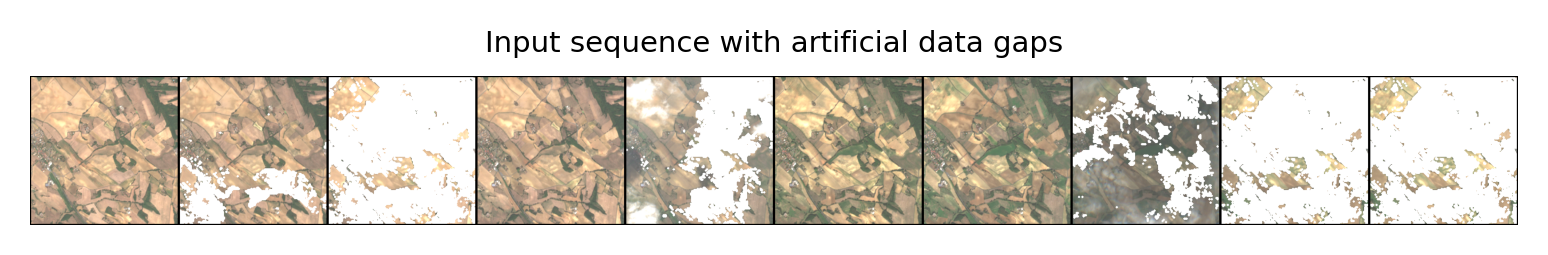

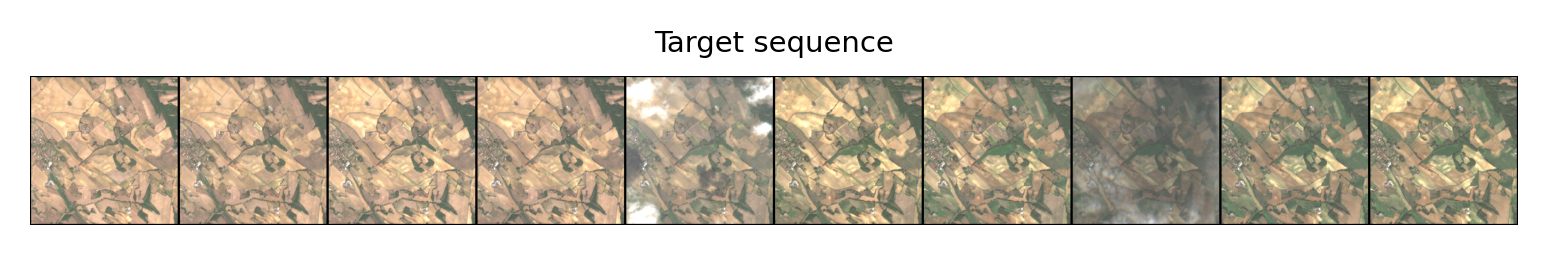

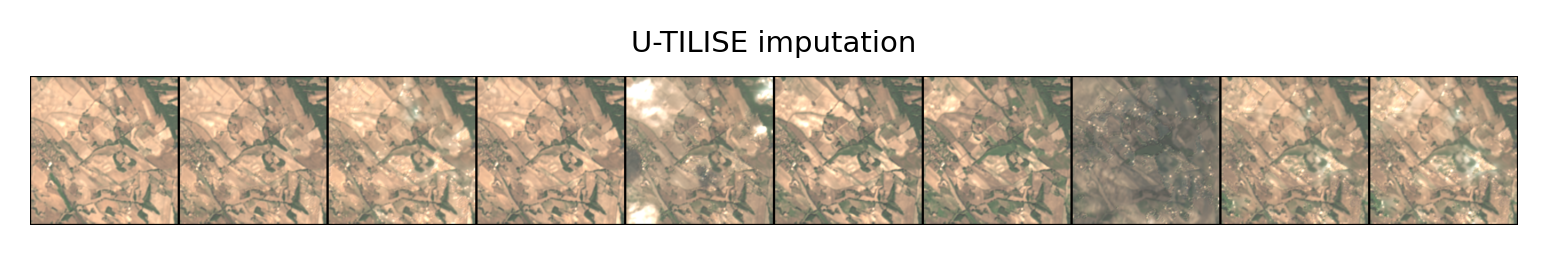

In [236]:
index = 14
sample = get_sample(test_loader, index)
batch, y_pred, att = inference_imputation.impute_sample(
    batch=sample,
    t_start=0,
    t_end=10,
    return_att=True,
)

# print("Analyse rapide des sorties de l'inférence:")
# print(sample.keys())
# print(sample["x"].shape)
# print(sample["y"].shape)
# print(sample.keys())
# print(y_pred.shape)
# print(batch.keys())
# print(batch["x"].shape)
# print(batch["y"].shape)

# Let's visualize the sequences
brightness_factor = 3
indices_rgb = batch['c_index_rgb'][0]

fig = visutils.sequence2gallery(batch['x'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Input sequence with artificial data gaps', fontsize=7)

fig = visutils.sequence2gallery(batch['y'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Target sequence', fontsize=7)

fig = visutils.sequence2gallery(y_pred[0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('U-TILISE imputation', fontsize=7)

### Calcul de métrique pour une inférence

In [131]:
training_config_file.metrics

{'masked_metrics': True, 'mae': True, 'mse': True, 'rmse': True, 'ssim': True, 'psnr': True, 'sam': True}

In [147]:
from lib.metrics import EvalMetrics
compute_metrics = EvalMetrics(training_config_file.metrics)
metrics_on_sample = compute_metrics(batch, y_pred)
print("**Metrics on the sample:**")
for k, v in metrics_on_sample.items():
    print(f"{k}: {v:.4f}")

**Metrics on the sample:**
ssim: 0.8958
masked_mae: 0.0202
masked_rmse: 0.0318
masked_mse: 0.0010
masked_psnr: 29.9574
masked_sam: 0.0517


In [159]:
# N'utilise pas les métriques masquées
metrics_config = training_config_file.metrics.copy()
metrics_config.masked_metrics = False
metrics_config.sam = False
metrics_config.eval_occluded_observed = True  # permet d'avoir des métriques pour les masked/observed/oa
compute_metrics = EvalMetrics(metrics_config)
metrics_on_sample = compute_metrics(batch, y_pred)
print("**Metrics on the sample:**")
for k, v in metrics_on_sample.items():
    print(f"{k}: {v:.4f}")

**Metrics on the sample:**
ssim: 0.8958
ssim_images_occluded_input_pixels: 0.8876
ssim_images_observed_input_pixels: 0.9694
masked_mae: 0.0214
masked_mae_occluded_input_pixels: 0.0295
masked_mae_observed_input_pixels: 0.0101
masked_rmse: 0.0328
masked_rmse_occluded_input_pixels: 0.0409
masked_rmse_observed_input_pixels: 0.0156
masked_mse: 0.0011
masked_mse_occluded_input_pixels: 0.0017
masked_mse_observed_input_pixels: 0.0002
masked_psnr: 29.6714
masked_psnr_occluded_input_pixels: 27.7605
masked_psnr_observed_input_pixels: 36.1114


### Observation des données de Célestin

In [72]:
import rasterio
import json
import numpy as np
from pathlib import Path

In [73]:
store_dai  = Path("/mnt/stores/store-dai")
path_data_Celest1 = store_dai / "projets/pac/3str/EXP_2/Data_Raster/test_v2"

def retrieve_dates_json_file_for_tif_file(
    tif_file: Path
) -> Dict[str, Any]:
    """
    Retrieve the dates.json file corresponding to the given TIF file.
    """
    json_file = tif_file.parent / "dates.json"
    if not json_file.exists():
        raise FileNotFoundError(f"JSON file {json_file} does not exist.")    
    return (tif_file, json_file)


# test set version aléatoire
folder_data_aleatoire = path_data_Celest1 / "aleatoire"  # test set version aléatoire
list_tif_aleatoire = list(folder_data_aleatoire.rglob("*.tif"))
dict_files_aleatoire = {}
for tif_file in list_tif_aleatoire:
    try:
        tif_file, json_file = retrieve_dates_json_file_for_tif_file(tif_file)
        dict_files_aleatoire[tif_file.name] = {
            "tif": tif_file,
            "json": json_file
        }
    except FileNotFoundError as e:
        print(f"Skipping file {tif_file}: {e}")

print("Nombre de zone MGRSC prise en compte dans le jeu de test:", len(list_tif_aleatoire))

Nombre de zone MGRSC prise en compte dans le jeu de test: 30


In [74]:
NUM_SEN2_BANDS = 12
f = list_tif_aleatoire[0]
dates_dict = json.load(open(dict_files_aleatoire[f.name]["json"]))
print("Data analysis on file:", f.name)
with rasterio.open(f) as src:
    data = src.read()
    print(f"Shape of the data: {data.shape}")
    print(f"Data type: {data.dtype}")
    print(f"Number of bands: {src.count}")
    print(f"CRS: {src.crs}")
    print(f"Transform: {src.transform}")

    data = data.reshape(len(dates_dict), NUM_SEN2_BANDS, src.width, src.height)  # Assuming the data is reshaped to (time_steps, height, width, channels)

Data analysis on file: bands_stacked_31TGJ_row-2_col-2.tif
Shape of the data: (924, 2196, 2196)
Data type: uint16
Number of bands: 924
CRS: EPSG:32631
Transform: | 10.00, 0.00, 721919.49|
| 0.00,-10.00, 4878062.73|
| 0.00, 0.00, 1.00|


In [75]:
print(data.shape)

(77, 12, 2196, 2196)


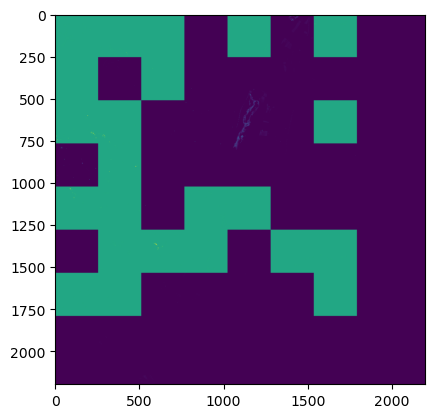

In [78]:
plt.imshow(data[0, 10, :, :])

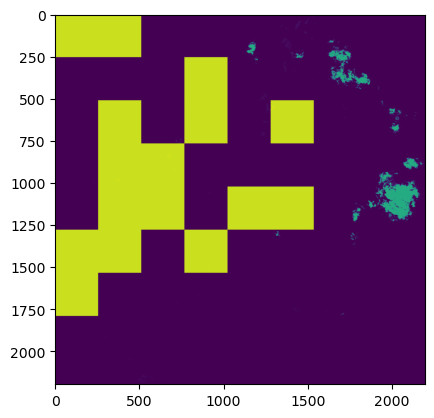

In [84]:
plt.imshow(data[3, 10, :, :])

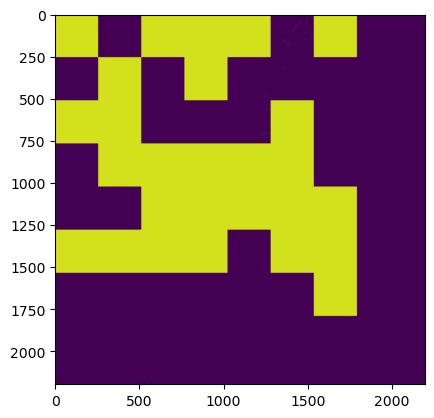

In [82]:
plt.imshow(data[2, 10, :, :])

In [89]:
for t in range(data.shape[0]):
    print(data[t, 10, 256:512, 256:512].mean())

0.02557373046875
59.20831298828125
150.00006103515625
0.00030517578125
0.00067138671875
0.00030517578125
100.0
150.00091552734375
0.020751953125
0.06951904296875
65.0
150.0015869140625
0.05731201171875
0.01953125
150.00311279296875
0.001220703125
150.00152587890625
0.0042724609375
0.0233154296875
14.73492431640625
65.0
100.0
0.0030517578125
0.00152587890625
0.072021484375
87.8829345703125
150.0003662109375
0.34710693359375
0.0001220703125
150.00018310546875
0.0001220703125
6.103515625e-05
6.103515625e-05
100.0
59.34051513671875
0.0
35.75592041015625
150.000244140625
0.0
14.7310791015625
150.0
57.1124267578125
59.754150390625
1.607421875
150.0
0.0
92.7667236328125
150.00006103515625
15.65887451171875
10.06219482421875
100.0
0.00030517578125
58.83941650390625
2.43359375
1.5577392578125
2.61468505859375
1.69952392578125
0.0001220703125
0.001220703125
0.00018310546875
0.00018310546875
150.0032958984375
72.81463623046875
0.00091552734375
30.67376708984375
150.00018310546875
0.0001220703125


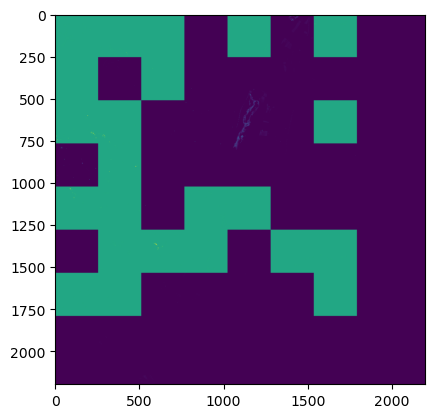

In [83]:
plt.imshow(data[0, 10, :, :])

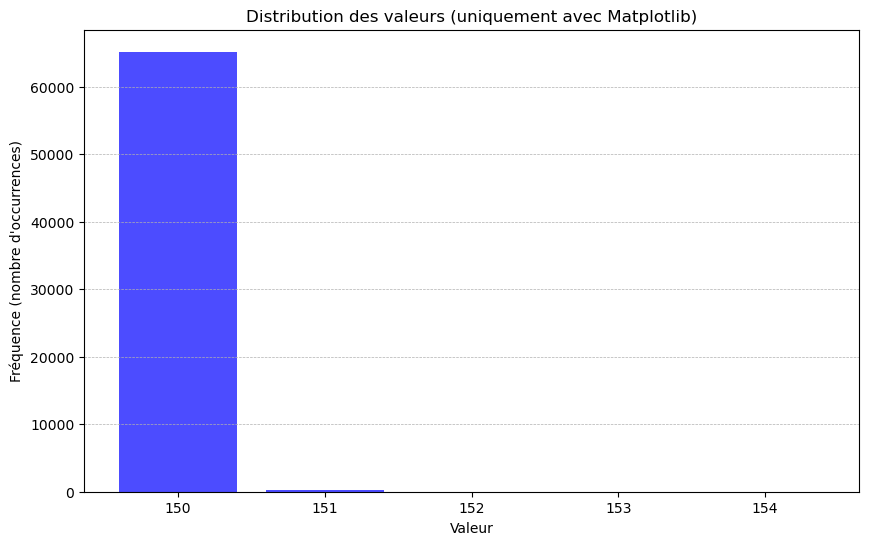

In [216]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Création du tableau de données NumPy
arr = data[0, 10, 0:256, 0:256]

# 2. Calcul des valeurs uniques et de leur fréquence
valeurs_uniques, comptes = np.unique(arr, return_counts=True)

# --- Création du graphique avec Matplotlib uniquement ---

# 3. Initialisation de la figure
plt.figure(figsize=(10, 6))

# 4. Création du diagramme en barres
# - Le premier argument est la position des barres sur l'axe X (nos valeurs uniques)
# - Le deuxième argument est la hauteur des barres (leurs comptes)
plt.bar(valeurs_uniques, comptes, color='blue', alpha=0.7)

# 5. Ajout des titres et des étiquettes pour rendre le graphique lisible
plt.title("Distribution des valeurs (uniquement avec Matplotlib)")
plt.xlabel("Valeur")
plt.ylabel("Fréquence (nombre d'occurrences)")

# 6. S'assurer que toutes les valeurs uniques sont affichées sur l'axe X
# C'est utile si les valeurs ne sont pas consécutives (comme ici avec l'absence de 0)
plt.xticks(valeurs_uniques)

# 7. Ajout d'une grille pour faciliter la lecture des hauteurs
plt.grid(axis='y', linestyle='--', linewidth=0.5)

# 8. Affichage du graphique final
plt.show()

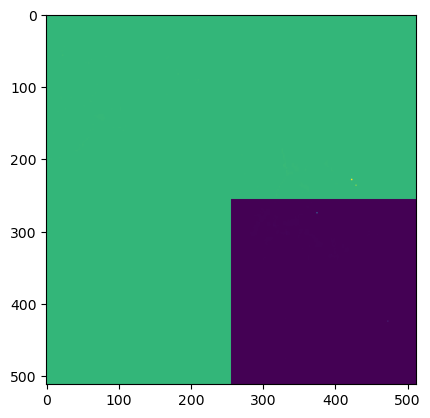

In [10]:
plt.imshow(data[0, 10, 0:512, 0:512])

In [14]:
# Ressortir les masks réels de nuages avec un retranchement de -150
cloud_probs_window = data[0, 10, 256:, 256:]
cloud_probs_window.mean()


# real_cloud_probs: list = []
# index_syn_mask: list = []
# for i, mask_window in enumerate(cloud_probs_window):
#     if mask_window.mean() > 150:
#         real_cloud_probs.append(mask_window - 150)
#         index_syn_mask.append(i)
#     else:
#         real_cloud_probs.append(mask_window)
# real_cloud_probs: np.ndarray = np.stack(real_cloud_probs, axis=0)

36.62919863960038

### Appariement S1 to S2

In [5]:
import datetime
import json
import os
from pathlib import Path

import numpy as np
from tqdm import tqdm

In [4]:
def get_datetime(date):
    year = int(date[:4])
    month = int(date[4:6])
    day = int(date[6:])
    return datetime.datetime(year, month, day)


def convert_dates(dates):
    dates_list = []
    d0 = datetime.datetime(2022, 9, 1)
    for date in dates:
        ecart = get_datetime(date) - d0
        dates_list.append(ecart.days)
    return np.array(dates_list)


def appariement(
    S2_dates,
    S1_dates_asc,
    S1_dates_desc,
):
    S1_dates_asc_int = convert_dates(S1_dates_asc)
    S1_dates_desc_int = convert_dates(S1_dates_desc)
    S2_dates_int = convert_dates(S2_dates)

    S1_dates_int = np.concatenate([S1_dates_asc_int, S1_dates_desc_int])
    indices = np.argsort(S1_dates_int)
    S1_dates_int = S1_dates_int[indices]

    S1_dates_tmp = S1_dates_asc + S1_dates_desc

    S1_dates = []
    for i in range(indices.shape[0]):
            S1_dates.append(S1_dates_tmp[indices[i]])

    S1_dates = np.array(S1_dates)
    distance = np.abs(np.expand_dims(S1_dates_int, 1) - np.expand_dims(S2_dates_int, 0))
    id_min = np.argmin(distance, axis=1)
    delta_min = np.min(distance, axis=1)

    dict_appariement = {}
    for i in range(S1_dates_int.shape[0]):
        if np.abs(delta_min[i]) <= 3:
            dict_appariement[S1_dates[i]] = S2_dates[id_min[i]]
        else:
            dict_appariement[S1_dates[i]] = None

    return dict_appariement

In [10]:
dates_s2 = ['20220903', '20220908', '20220913', '20220918', '20220923', '20220928', '20221003', '20221008', '20221013', '20221018', '20221023', '20221028', '20221102', '20221107', '20221112', '20221117', '20221122', '20221127', '20221207', '20221212', '20221217', '20221227', '20230106', '20230111', '20230116', '20230121', '20230126', '20230131', '20230205', '20230210', '20230215', '20230220', '20230225', '20230302', '20230307', '20230312', '20230317', '20230327', '20230401', '20230421', '20230426', '20230501', '20230506', '20230511', '20230516', '20230521', '20230526', '20230531', '20230605', '20230610', '20230615', '20230620', '20230625', '20230630', '20230705', '20230710', '20230715', '20230720', '20230725', '20230730', '20230804', '20230809', '20230814', '20230819', '20230824', '20230829', '20230903', '20230908', '20230913', '20230918', '20230923', '20230928']
dates_s1_asc = ['20220919', '20220924', '20221001', '20221006', '20221013', '20221025', '20221106', '20221111', '20221118', '20221123', '20221130', '20221205', '20221212', '20221217', '20221224', '20221229', '20230105', '20230110', '20230117', '20230122', '20230129', '20230203', '20230210', '20230215', '20230222', '20230227', '20230306', '20230311', '20230318', '20230323', '20230330', '20230404', '20230411', '20230416', '20230423', '20230428', '20230505', '20230510', '20230517', '20230522', '20230529', '20230603', '20230610', '20230615', '20230622', '20230627', '20230704', '20230709', '20230716', '20230721', '20230728', '20230802', '20230809', '20230814', '20230821', '20230826']
dates_s1_desc = ['20220916', '20220923', '20220928', '20221005', '20221010', '20221017', '20221022', '20221029', '20221103', '20221110', '20221115', '20221122', '20221127', '20221204', '20221209', '20221216', '20221221', '20221228', '20230102', '20230109', '20230114', '20230121', '20230126', '20230207', '20230219', '20230226', '20230303', '20230310', '20230315', '20230322', '20230327', '20230403', '20230408', '20230415', '20230420', '20230427', '20230502', '20230509', '20230514', '20230521', '20230526', '20230602', '20230607', '20230614', '20230619', '20230626', '20230701', '20230708', '20230713', '20230720', '20230725', '20230801', '20230806', '20230813', '20230818', '20230825', '20230830']

print(f"{len(dates_s2)=}")
print(f"{len(dates_s1_asc)=}")
print(f"{len(dates_s1_desc)=}")

len(dates_s2)=72
len(dates_s1_asc)=56
len(dates_s1_desc)=57


In [55]:
S2_dates, S1_dates_asc, S1_dates_desc = dates_s2, dates_s1_asc, dates_s1_desc

S1_dates_asc_int = convert_dates(S1_dates_asc)
S1_dates_desc_int = convert_dates(S1_dates_desc)
S2_dates_int = convert_dates(S2_dates)

S1_dates_int = np.concatenate([S1_dates_asc_int, S1_dates_desc_int])
indices = np.argsort(S1_dates_int)
S1_dates_int = S1_dates_int[indices]

S1_dates_tmp = S1_dates_asc + S1_dates_desc

S1_dates = []
for i in range(indices.shape[0]):
        S1_dates.append(S1_dates_tmp[indices[i]])
S1_dates = np.array(S1_dates)

dict_appariement_S2_S1_asc = {}
list_index_prelevement_asc = [] 
distance_S2_S1_asc = np.abs(np.expand_dims(S2_dates_int, 1) - np.expand_dims(S1_dates_asc_int, 0))
id_min_S2_S1_asc = np.argmin(distance_S2_S1_asc, axis=1)
for i in range(len(S2_dates)):
    date_min = S1_dates_asc[id_min_S2_S1_asc[i]]
    orbit_type = "ASC"
    index_prelevement_asc = S1_dates_asc.index(date_min)
    if index_prelevement_asc not in list_index_prelevement_asc:
        list_index_prelevement_asc.append(index_prelevement_asc)
    index_in_new_data_asc = list_index_prelevement_asc.index(index_prelevement_asc)
    dict_appariement_S2_S1_asc[S2_dates[i]] = (date_min, orbit_type, index_in_new_data_asc)

dict_appariement_S2_S1_desc = {}
list_index_prelevement_desc = []
distance_S2_S1_desc = np.abs(np.expand_dims(S2_dates_int, 1) - np.expand_dims(S1_dates_desc_int, 0))
id_min_S2_S1_desc = np.argmin(distance_S2_S1_desc, axis=1)
for i in range(len(S2_dates)):
    date_min = S1_dates_desc[id_min_S2_S1_desc[i]]
    orbit_type = "DESC"
    index_prelevement_desc = S1_dates_desc.index(date_min)
    if index_prelevement_desc not in list_index_prelevement_desc:
        list_index_prelevement_desc.append(index_prelevement_desc)
    index_in_new_data_desc = list_index_prelevement_desc.index(index_prelevement_desc)
    dict_appariement_S2_S1_desc[S2_dates[i]] = (date_min, orbit_type, index_in_new_data_desc)


dates_S1_ASC_collected = np.asarray(S1_dates_asc)[list_index_prelevement_asc].tolist()
dates_S1_DESC_collected = np.asarray(S1_dates_desc)[list_index_prelevement_desc].tolist()

# Détermination si la donnée SAR la plus proche temporellement est ASC ou DESC
distance_S2_S1_all = np.abs(np.expand_dims(S2_dates_int, 1) - np.expand_dims(S1_dates_int, 0))
id_min_S2_S1_all = np.argmin(distance_S2_S1_all, axis=1)
dict_appariement_S2_S1_all = {}
for i in range(len(S2_dates)):
    date_min = S1_dates[id_min_S2_S1_all[i]]
    if date_min in S1_dates_asc:
        orbit_type = "ASC"
        index = dates_S1_ASC_collected.index(date_min)
    else:
        orbit_type = "DESC"
        index = dates_S1_DESC_collected.index(date_min)
    dict_appariement_S2_S1_all[S2_dates[i]] = (date_min, orbit_type, index)

print(f"{len(dates_s2)=}")
print(f"{len(dates_s1_asc)=}")
print(f"{len(dates_s1_desc)=}")
print(f"#######INTERVAL##########")
print(f"{len(S1_dates_asc_int)=}")
print(f"{len(S1_dates_desc_int)=}")
print(f"{len(S2_dates_int)=}")
print(f"{len(S1_dates_int)=}")
print(f"{len(indices)=}")
print(f"{len(S1_dates)=}")


len(dates_s2)=72
len(dates_s1_asc)=56
len(dates_s1_desc)=57
#######INTERVAL##########
len(S1_dates_asc_int)=56
len(S1_dates_desc_int)=57
len(S2_dates_int)=72
len(S1_dates_int)=113
len(indices)=113
len(S1_dates)=113


In [62]:
store_dai = Path("/mnt/stores/store-dai")
hdf5_file = Path("/DATA_10TB/data_rpg/circa/hdf5/circa_cloud_removal_asc_desc.hdf5")
assert hdf5_file.exists()

In [ ]:
import h5py
